# 🚗 Predicting Car Prices with Machine Learning

Welcome, data explorers! 👩‍💻👨‍💻🚀

Imagine you're browsing through a car dealership’s website and wondering — *"Why is this car more expensive than that one?"* 🤔  
Well, today **you’re the data scientist behind the scenes**, building a model that helps answer exactly that.

In this case study, you and your team will work on an **end-to-end machine learning project** to **predict car prices** based on various features like the model, year, mileage, fuel type, and more. We'll be using a real-world dataset from the automotive market — noisy, messy, and full of patterns waiting to be discovered. 🧠📊

You'll walk through the full ML pipeline:  
- Cleaning and preprocessing the data 🧹  
- Exploring the hidden relationships 🔍  
- Building and tuning regression models 🛠️  
- Evaluating how well your model performs 📈  
- And maybe... deploying it? (ambitious, but hey — dream big!)

By the end of this notebook, you’ll have built a model that can **predict the price of a car**, and more importantly, you'll understand how to tackle real-world machine learning problems from scratch.

Let’s rev up our engines and start predicting! 🏁💥


#### First, let's take a look at our dataset

In [1]:

import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/predict_prices_dataset.csv')
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi
5,A1,2016,13900,Automatic,32260,Petrol,30,58.9,1.4,audi
6,A6,2016,13250,Automatic,76788,Diesel,30,61.4,2.0,audi
7,A4,2016,11750,Manual,75185,Diesel,20,70.6,2.0,audi
8,A3,2015,10200,Manual,46112,Petrol,20,60.1,1.4,audi
9,A1,2016,12000,Manual,22451,Petrol,30,55.4,1.4,audi


#### 2. Explore the Dataset (EDA - Exploratory Data Analysis)
Understand the structure and content:

Shape of the dataset

Data types

Missing values

Statistical summary

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  str    
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  str    
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  str    
 6   tax           72435 non-null  int64  
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 7.1 MB


In [3]:
# Summary statistics
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000
mean,2017.073666,16579.987506,23176.517057,116.953407,55.852480,1.635650
std,2.101252,9299.218027,21331.515562,64.045533,17.114391,0.561535
min,1996.000000,99.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10175.000000,7202.500000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17531.000000,145.000000,55.400000,1.600000
75%,2019.000000,20361.000000,32449.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


#### Let's get some insights

🔧 Year: 
- Mean year of cars is ~2017, with a range from 1996 to 2020.
- 75% of the cars are from 2016 or newer, indicating the dataset is mostly composed of recent vehicles.
- The standard deviation (~2.1 years) shows low year variability — mostly modern cars.

💰 Price
- Car prices range from as low as £495 to £145,000 — this is a huge spread, likely including luxury and budget models.
- The average price is around £16,580, with a median of £14,495, suggesting a right-skewed distribution (some very expensive outliers).

🛣️ Mileage
- Mileage spans from 0 to 323,000 miles — a massive range.
- Median mileage is around 17,531, and the mean is 23,176, again showing a right-skewed distribution (many high-mileage cars).

💸 Tax
- Tax ranges from £0 to £580, with a median of £145, which likely reflects common tax bands.
- Mean tax is ~£117, and 75% of cars fall below £145 — outliers should be reviewed here as well.

⛽ MPG (Miles per Gallon)
- Extremely wide range from 0.3 to 470.8 MPG — the upper value is almost certainly an anomaly or data entry error (possibly electric vehicles with an equivalent mpg).
- Median of 55.4 MPG, and average of ~55.85, suggesting mostly fuel-efficient vehicles.

🔧 Engine Size
- Engine sizes range from 0.0 to 6.6 liters, with median = 1.6L, which aligns with common car engines.
- Some 0.0 engine sizes might indicate missing or erroneous values.
- Values above 4.0L likely belong to high-performance/luxury cars.

#### Do we have missing values??

In [4]:
# Check for missing values
df.isnull().sum()
# df.fillna(0).count()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

###### Handling Missing Values – Quick Decision Guide

---

###### 1) Identify Feature Type
- **Categorical (`make`, `model`)** → Mode, `"Unknown"`, or predictive modeling  
- **Numerical (`price`, `mileage`, `engineSize`)** → Mean/Median, group-wise stats, or regression/KNN  
- **Ordinal (e.g., condition 1–5)** → Median or interpolation  

---

###### 2) Check Missingness Percentage
- **<5%** → Simple imputation (mean/median/mode)  
- **5–30%** → Group-wise or model-based imputation  
- **>30%** → Consider dropping or advanced methods  

---

###### 3) Determine Missingness Mechanism
- **MCAR** (*Completely Random – e.g., data entry errors*) → Mean/median (num), Mode (cat)  
- **MAR** (*Depends on other features – e.g., mileage missing in new cars*) → Group-wise, Regression, or KNN  
- **MNAR** (*Depends on the value itself – e.g., high-priced cars hiding price*) → Keep as `NaN`, or add `"missing"` flag  

---

###### 4) Check Data Ordering
- **Sequential/Time-series** → FFILL/BFILL **within groups only**  
- **Unordered (typical listings)** → Prefer statistical or model-based methods; **avoid FFILL/BFILL**  

---

###### 5) Quick Reference Table

| Situation                | Recommended Method                          |
|---------------------------|---------------------------------------------|
| Categorical, low missing  | Mode or `"Unknown"` category                |
| Numerical, MCAR           | Mean or median                              |
| Numerical, MAR            | Group-wise median/mean, KNN, or regression  |
| Numerical, MNAR           | Keep as `NaN` or add `"missing"` flag       |
| Sequential data           | FFILL/BFILL within same group only          |

---

###### 6) Best Practices
✔ Analyze missingness before imputing  
✔ Group by similar characteristics (`make`, `model`) when filling  
✔ Never propagate values across unrelated groups  
✔ Test model performance **with & without** imputation  

---


#### Load dataset again to see it here

In [5]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0,78.4,1.6,Hyundai
72431,I40,2015,7830,Manual,59508,Diesel,30,65.7,1.7,Hyundai
72432,I10,2017,6830,Manual,13810,Petrol,20,60.1,1.0,Hyundai
72433,Tucson,2018,13994,Manual,23313,Petrol,145,44.8,1.6,Hyundai


##### Ok, now take am moment to inspect the data closely. Which is the target variable? -in our case, the price. What car brands do we have, models, what fuel type corresponds to what model, and so on. 
##### The best way to do this is of course, using visual types of plots! 

📊 1. Distribution of Car Prices
Shows price skewness and outliers.

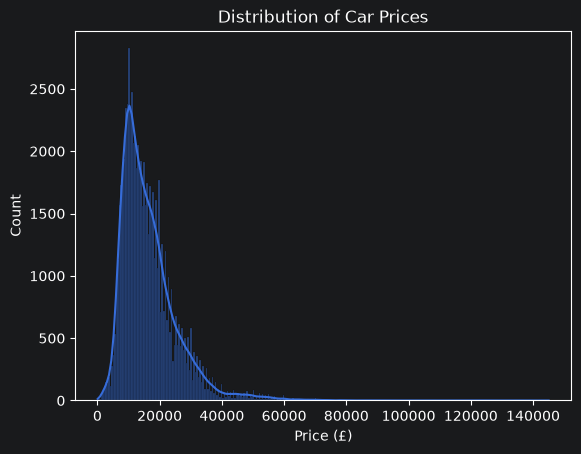

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], bins="auto", kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.show()



####  TODO: Write some conclusions 


## Conclusions:
 ##### - As expected, the dataset highlights a real-life situation: just like on the streets, there are way more "mid-range" or even "low-range" cars, and the very expensive ones are an exception.
 ##### -We also have cars with very low prices in the dataset, for example, an Audi A1 priced at £99.
##### - There are also high-price outliers which are actually normal for some car models. But we should analyze them separately because there are only a few of them.
##### - These extreme outliers will influence the model. We should filter out the super cheap cars so they don't mess up our regression model.

🧼 2. Boxplot of Price by Transmission Type
Compare prices across automatic vs manual cars.

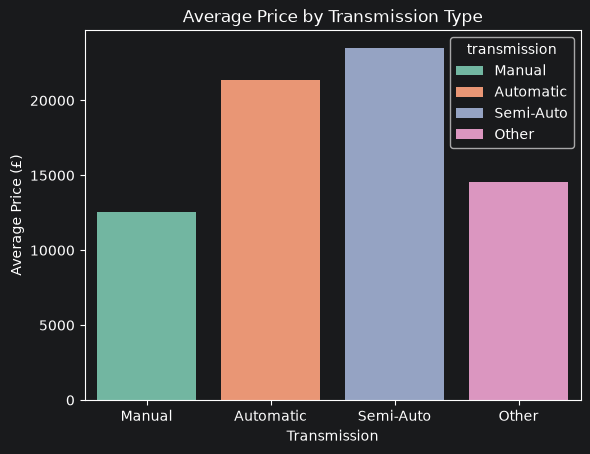

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use 'hue' to apply the palette per category
sns.barplot(
    x='transmission',
    y='price',
    data=df,
    hue='transmission',
    palette='Set2',
    errorbar=None,              
    legend=True             
)

plt.title('Average Price by Transmission Type')
plt.ylabel('Average Price (£)')
plt.xlabel('Transmission')
plt.xticks(rotation=0)
plt.show()

####  TODO: Write some conclusions 
## Conclusions:
##### - Based on the chart above, we can see that the price differs depending on the transmission type, so we can deduce a correlation between transmission and average price.
##### -Semi-automatic cars are the most expensive (~20k+), followed by automatic cars (also over 20k but lower than semi-auto).
##### -Manual cars are the cheapest (between 10k and 15k).
##### -This happens mostly because semi-auto and auto gearboxes are put on newer cars.



⛽ 3. Boxplot of Price by Fuel Type
Helps assess how fuel type affects car pricing.

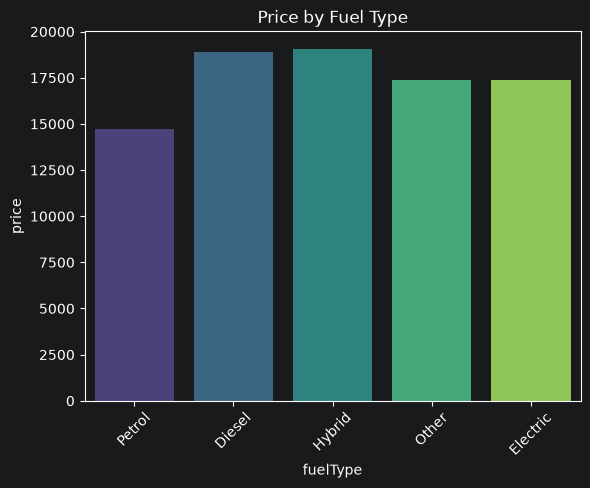

In [8]:


sns.barplot(x='fuelType', y='price', data=df, hue='fuelType',         
    palette='viridis',
    errorbar=None,              
    legend=False )
plt.title('Price by Fuel Type')
plt.xticks(rotation=45)
plt.show()

####  TODO: Write some conclusions 


## Conclusions:
##### -Just like the previous chart, this one highlights the correlation between fuel type and price.
##### -Hybrid cars are the most expensive, followed by diesel, and petrol cars are the cheapest.
##### - "Other" and "Electric" are roughly the same price fact that may create some confussions for the model on the next steps. The same goes for diesel and hybrid, but here the price difference is bigger, so it will be easier to tell them apart.


🏷️ 4. Average Price per Car Make
Top 15 brands only for readability.


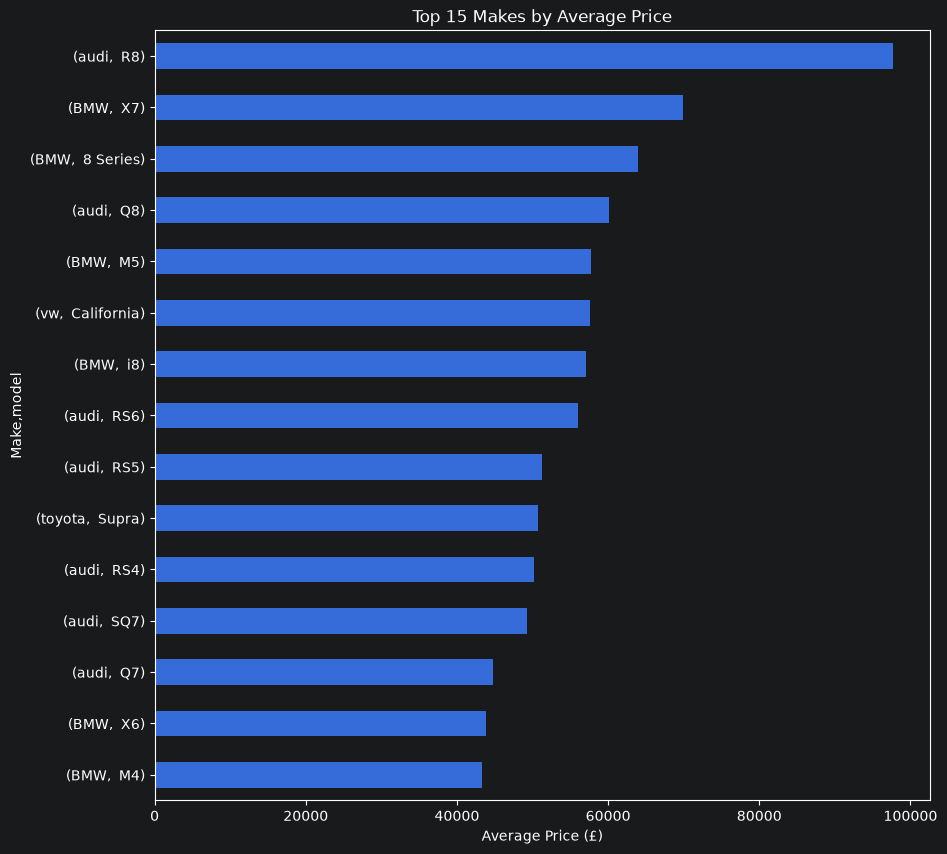

In [9]:
avg_price_by_make = df.groupby(['Make', 'model'])['price'].mean().sort_values(ascending=False).head(15)
avg_price_by_make.plot(kind='barh', figsize=(10, 10))
plt.xlabel('Average Price (£)')
plt.title('Top 15 Makes by Average Price')
plt.gca().invert_yaxis()
plt.show()

####  TODO: Write some conclusions 


## Conclusions:
##### -In this chart, we can see a deeper correlation between car make and price. BMW and Audi cars dominate in terms of price.
##### -However, we can also see VW and Toyota cars that are more expensive than some Audi and BMW models (like the VW California or Toyota Supra).
##### -This proves that a car's price is not only influenced by the make, but the specific model of the car matters a lot.
##### -Since the model column is so important visually, we shouldn't just drop it. But because it has so many different text names, we need a smart way to turn it into numbers for example, replacing the model name with its average price.

📈 5. Scatterplot of Mileage vs. Price
See depreciation pattern as mileage increases.

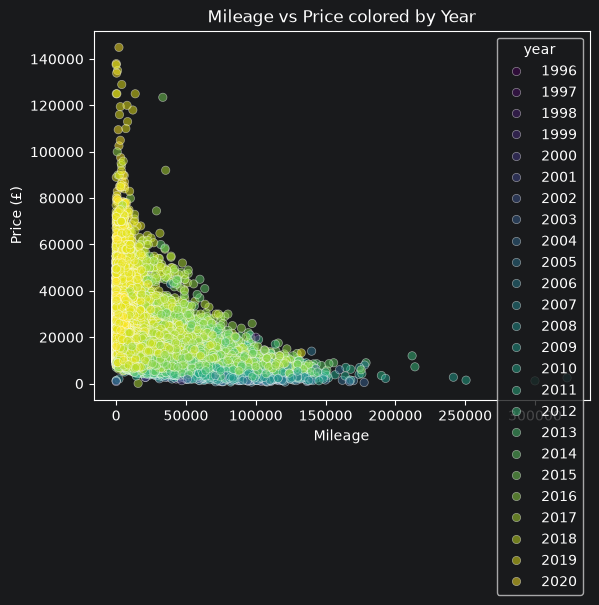

In [10]:
sns.scatterplot(x='mileage', y='price', data=df, alpha=0.5, hue='year', palette='viridis', legend='full')
plt.title('Mileage vs Price colored by Year')
plt.xlabel('Mileage')
plt.ylabel('Price (£)')
plt.show()

####  TODO: Write some conclusions 


## Conclusions:
##### -The first thing that stands out is the pattern between mileage and price. Cars with low kilometers (mainly the new ones) have higher prices.
##### -Basically, new cars have low mileage and older cars have more. So the older the car, the more kilometers it has, and the lower the price.
##### -We can also spot some clear outliers on the plot: new cars with low mileage but huge prices, and mid-year cars with lots of mileage that sit at the very bottom in price.
##### -The price drops really fast on the chart in the first few thousand miles, and then it flattens out.


📅 6. Price vs Year
Understand how newer cars are priced.

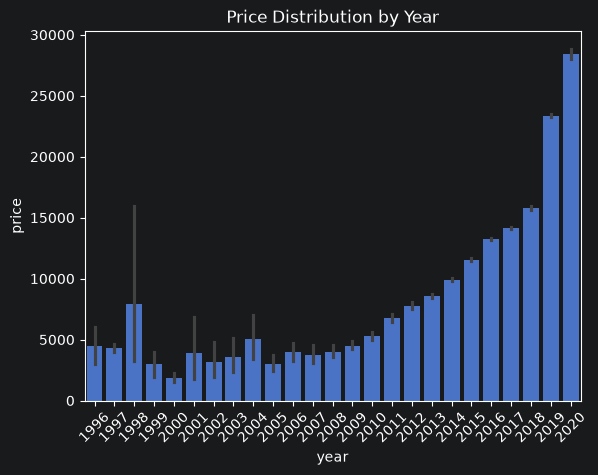

In [11]:
sns.barplot(x='year', y='price', data=df)
plt.title('Price Distribution by Year')
plt.xticks(rotation=45)
plt.show()

####  TODO: Write some conclusions

## Conclusions:
##### This chart highlights the correlation between year and price even better. At first glance, the rule is that new cars are more expensive than older ones.
##### -But we can see exceptions on the bars. The chart shows a car from 1998 that is more expensive than many newer cars, proving again that price depends on many factors combined.
##### -Old or vintage cars gain value instead of losing it. To keep things clean, we should filter out cars older than 2005 so they don't confuse our model's predictions for normal daily cars.

⚙️ 7. Engine Size vs Price
Bigger engines tend to cost more — is it true?

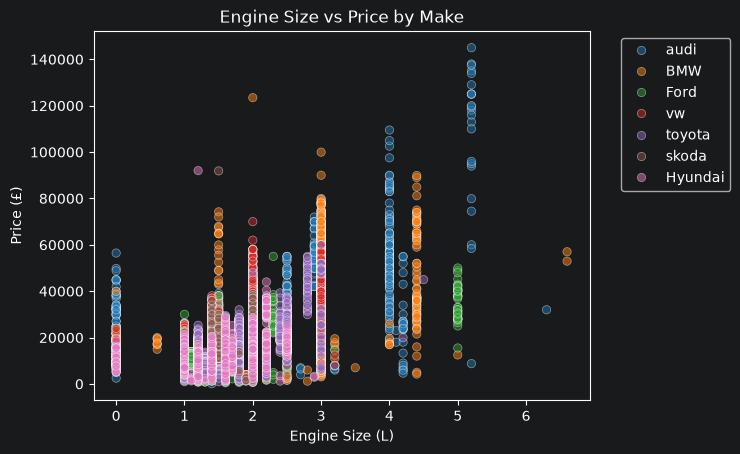

In [12]:
sns.scatterplot(x='engineSize', y='price', data=df, alpha=0.5, hue='Make', palette='tab10', legend='full')
plt.title('Engine Size vs Price by Make')
plt.xlabel('Engine Size (L)')
plt.ylabel('Price (£)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()

####  TODO: Write some conclusions

## Conclusions:
##### -This chart shows the correlation between engine size and price, which looks visually not the strongest considering some small engines are more expensive than bigger ones.
##### -The car make has a good weight here, but it's still not enough for correct predictions because the model is also an important factor.
##### -We can visually spot data points at the 0.0L mark on the axis. A 0.0L engine is mostly a mistake like missing data but it can be an electric engine that theoretically have 0 L. We must fix this by replacing the 0.0L with the median engine size for those specific models before training for the combustion engines .

🛣️ 8. MPG vs Price
Fuel efficiency vs cost.

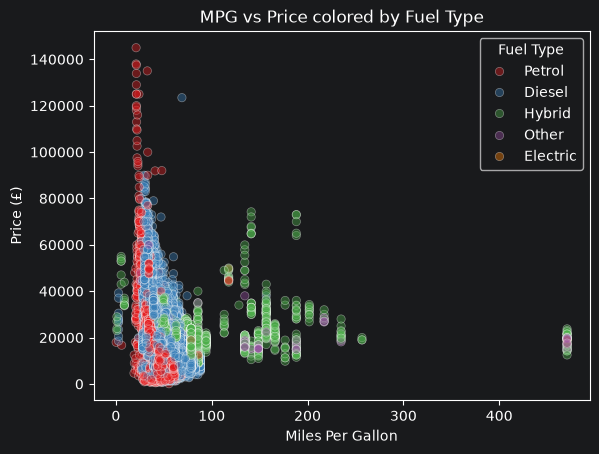

In [13]:
sns.scatterplot(x='mpg', y='price', data=df, alpha=0.4, hue='fuelType', palette='Set1')
plt.title('MPG vs Price colored by Fuel Type')
plt.xlabel('Miles Per Gallon')
plt.ylabel('Price (£)')
plt.legend(title='Fuel Type')
plt.show()

####  TODO: Write some conclusions

## Concluzii
##### -The chart shows a relatively stronger correlation between fuel type and car consumption than between price and consumption.
##### - We can see that diesel, electric, and petrol cars are basically grouped in the mid-range or low-range price area.
##### -Still, we can notice that the dots with very low consumption are the most expensive ones.
##### -This shows people are willing to pay a higher price upfront for a car that consumes less fuel. We can leave this column as it is, the data looks good on a first glance.

### Let's see how these are correlated to the price

📦 9. Correlation Heatmap
Find linear relationships between numeric features.

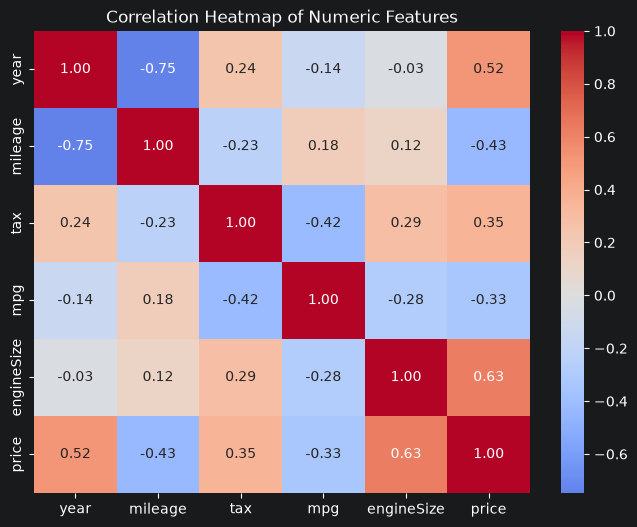

In [14]:
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [15]:
corr = df.corr(numeric_only=True)


C:\Users\NeagVasileDragos\AppData\Local\Temp\ipykernel_27012\3789713215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')


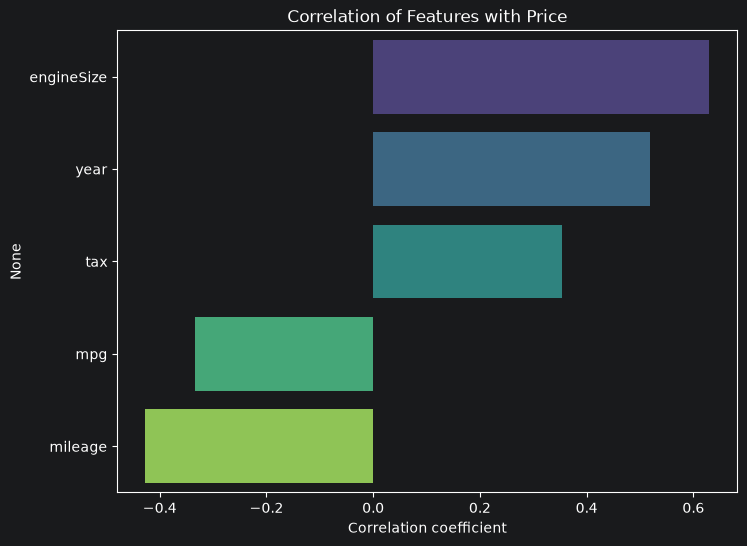

In [16]:

# Correlation with 'price' only
price_corr = corr['price'].sort_values(ascending=False)

# Drop 'price' itself for clarity
price_corr = price_corr.drop('price')

plt.figure(figsize=(8, 6))
sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation coefficient')
plt.show()

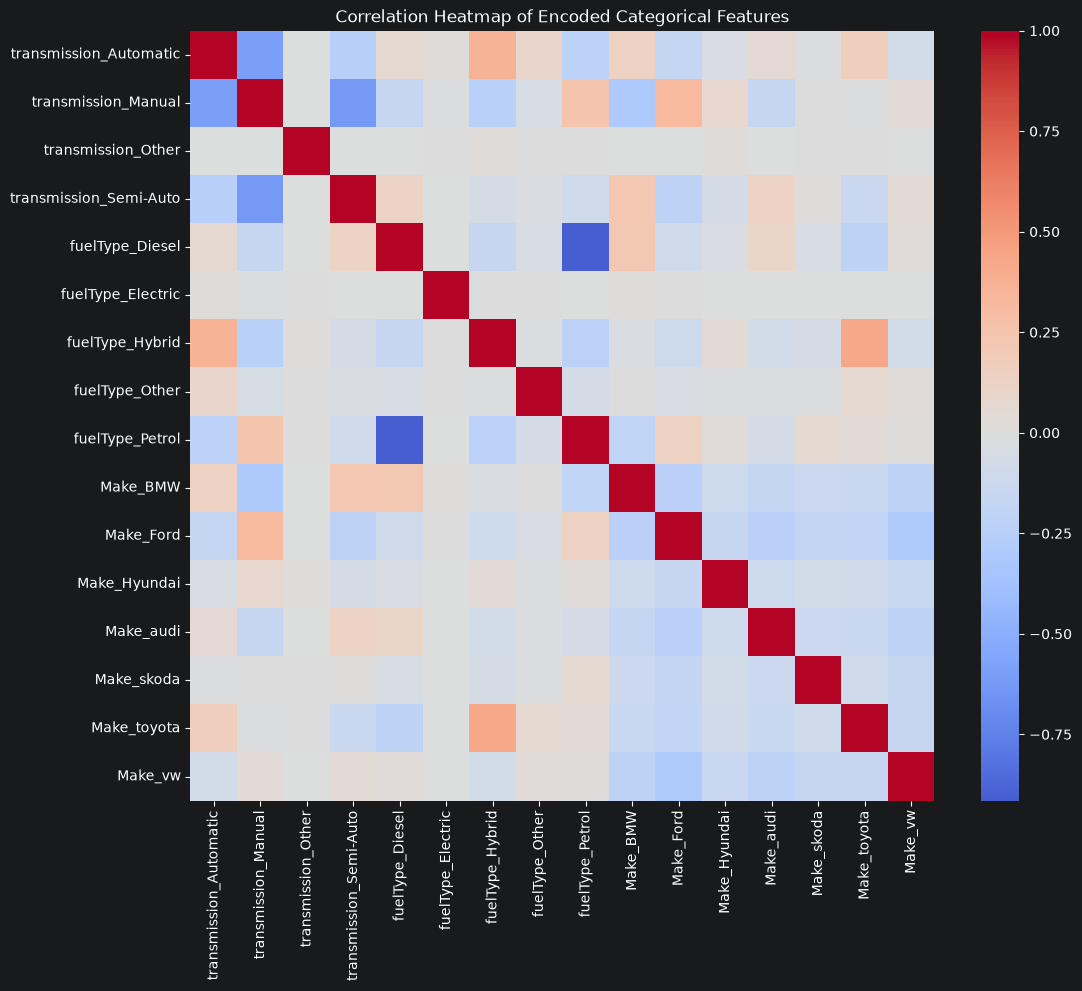

In [17]:
# Drop 'model' and encode categorical columns
df_no_model = df.drop(columns=['model'])
df_encoded = pd.get_dummies(df_no_model, columns=['transmission', 'fuelType', 'Make'])

# Select encoded categorical columns (exclude numeric)
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']
encoded_cols = [col for col in df_encoded.columns if col not in numeric_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded[encoded_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Encoded Categorical Features')
plt.show()

#### Ok, we have a lot of correlations here so we can draw a lot of conclusions. When a correlation is approaching to 1, it means that there is a strong correlation between two features, and they are directly proportional to one another. Where the correlation is close to 0, it does not indicate to much for us, no correlation. If the correlation is approaching to -1, it means that there is an inverse proportionality between those features: where one increases, the other one decreaases.

####  TODO: Write some conclusions

## For the last 10 conclusions, I will exclusively use the last 3 charts because they are the only ones left uncovered.

# Conclusions:

##### - From the first two charts, we can see a pretty strong direct correlation between engine size and price, highlighting that usually, the bigger the engine, the more expensive the car gets.
##### - Also from the first two charts, we can see another pretty strong correlation, but not as strong as the previous one, between the manufacturing year and the price. In general, newer cars are more expensive than older ones. But, just like I mentioned in the chart that shows price by year, this is not a universal rule. Some old cars can be more expensive than newer ones, which is why the correlation coefficient between these two is not huge (0.52).
##### - From the first chart, we can spot an inverse correlation between mileage and year. This highlights that as a car gets older, its mileage increases. Or better said, the newer a car is, the fewer kilometers it generally has, hence the correlation coefficient of -0.75 between the two.
##### - Still from the first two charts, we can also see the correlation between a car's mileage and its price. This is a relatively strong, inverse correlation, which shows that as a car's mileage increases, its price should normally drop.
##### - From the first chart, we can also see an inverse correlation between tax and mpg, from which we can deduce the idea that efficiency lowers taxes.
##### - From the last chart, we can see a pretty strong correlation between hybrid cars and automatic transmission. This correlation highlights a logical situation, considering that many hybrid cars are modern cars which usually have an automatic gearbox. On the other hand, petrol cars have a pretty good correlation with manual transmission, which tells us that many petrol cars are manual.
##### - Between petrol and diesel fuel types, there is a strong inverse correlation, which is logical: a car that runs on diesel can't run on petrol too. The same goes for the transmission types; there are pretty strong inverse correlations between them, highlighting that a car can't have both a manual and an automatic or semi-automatic transmission at the same time. It has to be just one.
##### - We can notice a good correlation between the Toyota make and the hybrid fuel type. This tells us that Toyota cars are mainly hybrid cars, and we could assume that they are newer cars.
##### - From the correlation between Ford cars and manual transmission, it stands out that Ford cars mainly have a manual gearbox. This fact is strengthened by the inverse correlation between this brand and the other types of transmissions.
##### - BMW cars generally have an automatic or semi-automatic transmission, which is highlighted by the correlation chart. There are pretty good correlations between the BMW make and these features, leading to the idea that premium brands generally use automatic or semi-automatic transmissions and diesel engines.

### Next steps:
- Feature Engineering: create new or transformed features that may better capture relationships (e.g. : Age of car: car_age = current_year - year, Binning mileage or engineSize into ranges, Log-transform skewed data (e.g., price, mileage), Interactions (e.g., mpg × engineSize))
- Encoding Categorical Features: perfect for transmission, fuelType, Make. Decide what to do with model column (high cardinality column)
- Feature Selection: 
     - You don't always want to keep everything. Good strategies include:
     - Use correlation with price (already done!)
     - SelectKBest, recursive feature elimination (RFE)
     - Model-based importance (e.g., .feature_importances_ from RandomForestRegressor)

#### Let's exemplify these two new features that were engineered based on already existing columns:

In [18]:
import datetime

current_year = datetime.datetime.now().year
df['car_age'] = current_year - df['year']

df[['year', 'car_age']].head()

,year,car_age
0,2017,9
1,2016,10
2,2016,10
3,2017,9
4,2019,7


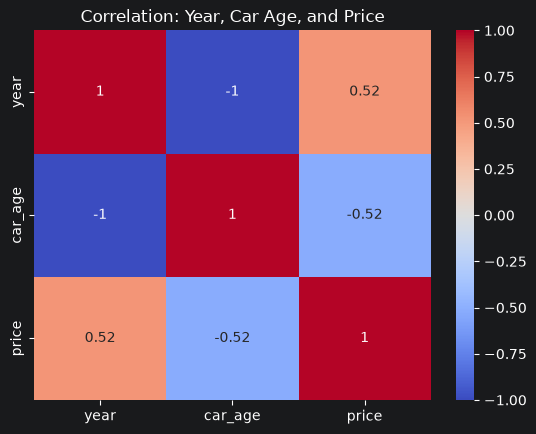

In [19]:
correlation_subset = df[['year', 'car_age', 'price']].corr()
sns.heatmap(correlation_subset, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Year, Car Age, and Price')
plt.show()

#### For example, it did not help. You can work with either car age or year, it gives the same stuff

In [20]:
# Define mileage bins
bins = [0, 10000, 30000, 60000, 100000, df['mileage'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# Check distribution
df['mileage_bin'].value_counts()

mileage_bin
Low          28207
Very Low     23584
Medium       15994
High          4060
Very High      590
Name: count, dtype: int64

#### Create bins for mileage

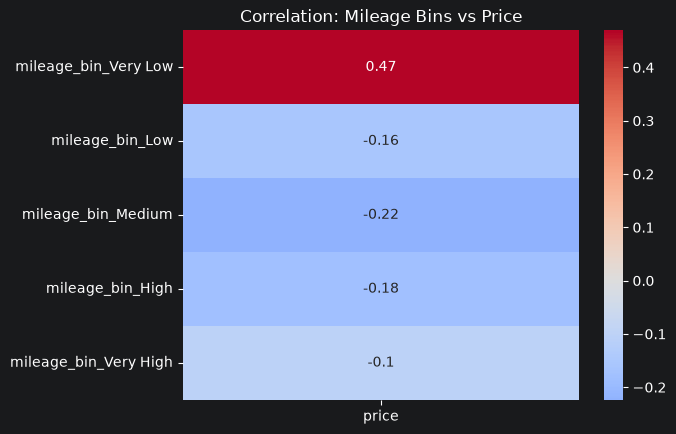

In [21]:
# 1. Define mileage bins
bins = [0, 10000, 30000, 60000, 100000, df['mileage'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# 2. One-hot encode the bin column
df_encoded_bins = pd.get_dummies(df[['mileage_bin', 'price']], drop_first=False)

# 3. Compute correlation matrix
corr_bins = df_encoded_bins.corr()

# 4. Show correlation of each bin with price
corr_with_price = corr_bins[['price']].drop('price')  # remove self-correlation

# 5. Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Mileage Bins vs Price')
plt.show()

#### TODO: is it helpful?

##### Yes, grouping the numbers into categories is helpful because it removes the "noise" and makes it easier to see how the mileage impacts the price evolution. For example, the heatmap shows very clearly that a low mileage increases the price, while a medium to high mileage decreases the price.

-try other ones

In [22]:
#Other rellevant binnings

#Year binning
bins_year=[1900, 2010, 2015,df['year'].max()]
labels_year=['Old','Mid-Age','New']

df['year_bin']=pd.cut(df['year'],bins=bins_year,labels=labels_year)

print("Year distribution:")

df['year_bin'].value_counts()

Year distribution:


year_bin
New        60062
Mid-Age    11428
Old          945
Name: count, dtype: int64

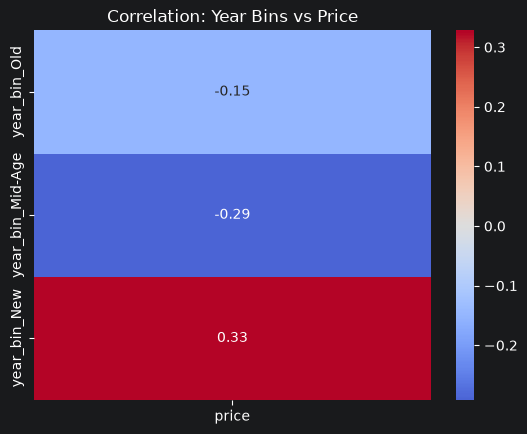

In [23]:
# 1. Define year bins
bins_year=[1900, 2010, 2015,df['year'].max()]
labels_year=['Old','Mid-Age','New']

df['year_bin'] = pd.cut(df['year'], bins=bins_year, labels=labels_year)

# 2. One-hot encode the bin column
df_encoded_bins = pd.get_dummies(df[['year_bin', 'price']], drop_first=False)

# 3. Compute correlation matrix
corr_bins = df_encoded_bins.corr()

# 4. Show correlation of each bin with price
corr_with_price = corr_bins[['price']].drop('price')  # remove self-correlation

# 5. Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Year Bins vs Price')
plt.show()

## About that diagram:

##### As expected the newer the car the higher the price , but the old year correlation with the price is not that strong as expected because of the exceptions showed in the previous diagrams with year and price where some old cars are more expensive than some mid age cars

In [24]:
#Engine Size binning
bins_engineSize=[-0.1,1.5 ,2.0,df['engineSize'].max()] #i used -0.1 to include the 0.0 L engines
labels_engineSize=['Small','Medium','Big']

df['engineSize_bin']=pd.cut(df['engineSize'],bins=bins_engineSize,labels=labels_engineSize)

print("Engine Size distribution:")

df['engineSize_bin'].value_counts()

Engine Size distribution:


engineSize_bin
Small     36088
Medium    30880
Big        5467
Name: count, dtype: int64

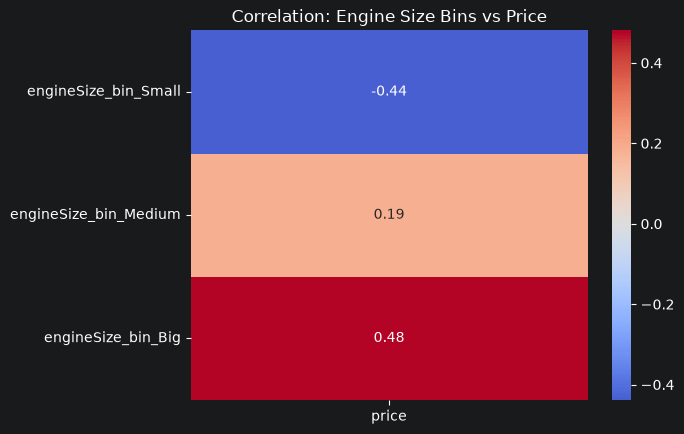

In [25]:
# 1. Define year bins
bins_engineSize=[-0.1, 1.5, 2.0,df['engineSize'].max()]
labels_year=['Small','Medium','Big']

df['engineSize_bin'] = pd.cut(df['engineSize'], bins=bins_engineSize, labels=labels_engineSize)

# 2. One-hot encode the bin column
df_encoded_bins = pd.get_dummies(df[['engineSize_bin', 'price']], drop_first=False)

# 3. Compute correlation matrix
corr_bins = df_encoded_bins.corr()

# 4. Show correlation of each bin with price
corr_with_price = corr_bins[['price']].drop('price')  # remove self-correlation

# 5. Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Engine Size Bins vs Price')
plt.show()

#### Let's go back to the dataset, since we have enough information

In [26]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age,mileage_bin,year_bin,engineSize_bin
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi,9,Low,New,Small
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi,10,Medium,New,Medium
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi,10,Low,New,Small
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi,9,Low,New,Medium
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi,7,Very Low,New,Small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0,78.4,1.6,Hyundai,10,Low,New,Medium
72431,I40,2015,7830,Manual,59508,Diesel,30,65.7,1.7,Hyundai,11,Medium,Mid-Age,Medium
72432,I10,2017,6830,Manual,13810,Petrol,20,60.1,1.0,Hyundai,9,Low,New,Small
72433,Tucson,2018,13994,Manual,23313,Petrol,145,44.8,1.6,Hyundai,8,Low,New,Medium


#### Categorical features need to be endoded

| Column         | Type             | Strategy                       | Notes                                    |
| -------------- | ---------------- | ------------------------------ | ---------------------------------------- |
| `transmission` | Categorical      | One-hot encoding               | Few categories                           |
| `fuelType`     | Categorical      | One-hot encoding               | Few categories                           |
| `Make`         | Categorical      | One-hot encoding               | Moderate number of brands (OK to encode) |
| `model`        | High-cardinality | Exclude or use target encoding | Too many unique values                   |
| `mileage_bin`  | Ordinal-ish      | Ordinal encoding or one-hot    | Low to high — either way works           |


In [27]:
mileage_bin_order = {'Very Low': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
df['mileage_bin_encoded'] = df['mileage_bin'].map(mileage_bin_order)


# Now create df_encoded, drop 'model' and 'mileage_bin' (keep mileage_bin_encoded)
df_encoded = df.drop(columns=['model', 'mileage_bin'])

# One-hot encode categorical variables (except mileage_bin_encoded which is numeric now)
df_encoded = pd.get_dummies(df_encoded, columns=['transmission', 'fuelType', 'Make'], drop_first=True)

In [28]:
df_encoded

,year,price,mileage,tax,mpg,engineSize,car_age,year_bin,engineSize_bin,mileage_bin_encoded,...,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,9,New,Small,1,...,False,False,False,True,False,False,True,False,False,False
1,2016,16500,36203,20,64.2,2.0,10,New,Medium,2,...,False,False,False,False,False,False,True,False,False,False
2,2016,11000,29946,30,55.4,1.4,10,New,Small,1,...,False,False,False,True,False,False,True,False,False,False
3,2017,16800,25952,145,67.3,2.0,9,New,Medium,1,...,False,False,False,False,False,False,True,False,False,False
4,2019,17300,1998,145,49.6,1.0,7,New,Small,0,...,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,10,New,Medium,1,...,False,False,False,False,False,True,False,False,False,False
72431,2015,7830,59508,30,65.7,1.7,11,Mid-Age,Medium,2,...,False,False,False,False,False,True,False,False,False,False
72432,2017,6830,13810,20,60.1,1.0,9,New,Small,1,...,False,False,False,True,False,True,False,False,False,False
72433,2018,13994,23313,145,44.8,1.6,8,New,Medium,1,...,False,False,False,True,False,True,False,False,False,False


#### Feature selection:  I will drop car_age since it is not helpful and also model because it has that huge cardinality

#### We have to decide to use mileage or binned column, mileage_bin_encoded. For now, we will stick to the original column

In [29]:
columns_to_drop = ['model', 'car_age', 'mileage_bin_encoded']
#df_encoded.drop(columns_to_drop, axis=1, inplace=True)
df_clean = df_encoded.drop(columns=columns_to_drop, errors='ignore')
df_clean

,year,price,mileage,tax,mpg,engineSize,year_bin,engineSize_bin,transmission_Manual,transmission_Other,...,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,New,Small,True,False,...,False,False,False,True,False,False,True,False,False,False
1,2016,16500,36203,20,64.2,2.0,New,Medium,False,False,...,False,False,False,False,False,False,True,False,False,False
2,2016,11000,29946,30,55.4,1.4,New,Small,True,False,...,False,False,False,True,False,False,True,False,False,False
3,2017,16800,25952,145,67.3,2.0,New,Medium,False,False,...,False,False,False,False,False,False,True,False,False,False
4,2019,17300,1998,145,49.6,1.0,New,Small,True,False,...,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,New,Medium,True,False,...,False,False,False,False,False,True,False,False,False,False
72431,2015,7830,59508,30,65.7,1.7,Mid-Age,Medium,True,False,...,False,False,False,False,False,True,False,False,False,False
72432,2017,6830,13810,20,60.1,1.0,New,Small,True,False,...,False,False,False,True,False,True,False,False,False,False
72433,2018,13994,23313,145,44.8,1.6,New,Medium,True,False,...,False,False,False,True,False,True,False,False,False,False


In [45]:
columns_to_drop=['year_bin','engineSize_bin']
df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')

In [46]:
bool_cols = df_clean.select_dtypes(include=['bool']).columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)



In [47]:
df_clean

,year,price,mileage,tax,mpg,engineSize,car_age,mileage_bin_encoded,transmission_Manual,transmission_Other,...,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,9,1,1,0,...,0,0,0,1,0,0,1,0,0,0
1,2016,16500,36203,20,64.2,2.0,10,2,0,0,...,0,0,0,0,0,0,1,0,0,0
2,2016,11000,29946,30,55.4,1.4,10,1,1,0,...,0,0,0,1,0,0,1,0,0,0
3,2017,16800,25952,145,67.3,2.0,9,1,0,0,...,0,0,0,0,0,0,1,0,0,0
4,2019,17300,1998,145,49.6,1.0,7,0,1,0,...,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,10,1,1,0,...,0,0,0,0,0,1,0,0,0,0
72431,2015,7830,59508,30,65.7,1.7,11,2,1,0,...,0,0,0,0,0,1,0,0,0,0
72432,2017,6830,13810,20,60.1,1.0,9,1,1,0,...,0,0,0,1,0,1,0,0,0,0
72433,2018,13994,23313,145,44.8,1.6,8,1,1,0,...,0,0,0,1,0,1,0,0,0,0


#### TODO: Consider improvements like Standardization or Normalization:

| Technique           | What it does                            | When to use                                                                                                                                                         |
| ------------------- | --------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Standardization** | Centers data to mean=0, std=1 (z-score) | When features have different units/scales, and your model assumes normality or is sensitive to scale (e.g., linear regression, logistic regression, SVM, k-NN, PCA) |
| **Normalization**   | Scales data to \[0,1] range             | When you want features in same scale but not necessarily centered, often useful for neural networks, distance-based models                                          |


#### Considering that this is a complete example and we will use the Random Forest Regressor as our model, we do not need to apply standardization or normalization. Random forest and other tree-based models are not scale-sensitive because they split data based on value thresholds not distance metrics.

# Next Steps for Your ML Pipeline

### 1. Split data into training and testing sets
- Use `train_test_split` (e.g., 80% train, 20% test) to evaluate your model’s performance on unseen data.

In [60]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((57948, 20), (14487, 20), (57948,), (14487,))


### 2. (Optional) Further feature engineering or selection
- Try feature importance or recursive elimination to reduce noise.
- Experiment with polynomial features or interaction terms if it makes sense.

### 3. Choose machine learning model(s)
- Start simple: Linear Regression, Decision Trees, Random Forest, Gradient Boosting.
- For regression, consider models like:  
  - Linear Regression  
  - RandomForestRegressor  
  - XGBoost / LightGBM  
  - Support Vector Regression (SVR)

In [62]:
# Initialize and train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)


### 4. Cross-validation
- Use K-Fold Cross Validation (e.g., 5 or 10 folds) on training set for robust performance estimation.
- Tune hyperparameters via grid search or random search within CV.

### TODO: perform cross-validation and choose best model! Play with parameters

In [86]:
#cross validation
from sklearn.model_selection import GridSearchCV

param_grid= {
    'n_estimators': [150],
    'max_depth':[30, 20 , None]
}
cv_model=GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
cv_model.fit(X_train, y_train)


Fitting 5 folds for each of 3 candidates, totalling 15 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [30, 20, ...], 'n_estimators': [150]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a cus

In [87]:
best_rf = cv_model.best_estimator_
print("best parameters combination:", cv_model.best_params_)

best parameters combination: {'max_depth': 20, 'n_estimators': 150}


### 5. Train final model on full training data
- Once hyperparameters are set, train model on all training data.

In [65]:
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o


### 6. Evaluate on test data
- Predict on test set.
- Calculate key metrics like:  
  - MAE (Mean Absolute Error)  
  - RMSE (Root Mean Squared Error)  
  - R² (Coefficient of Determination)


In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 1297.60
RMSE: 2309.11
R²: 0.940


MAE (Mean Absolute Error) = 1321.57
On average, your model's predicted car prices are off by about $1,322 from the actual prices. This is a direct measure of average prediction error in the same units as price.

RMSE (Root Mean Squared Error) = 2323.89
RMSE penalizes larger errors more than MAE because it squares the errors before averaging. An RMSE of ~$2,324 means larger errors exist, but overall the predictions are quite close. RMSE is more sensitive to outliers.

R² (Coefficient of Determination) = 0.939
This means your model explains about 93.9% of the variance in car prices. The closer to 1, the better the model fits the data. So 0.939 is excellent — your model predicts prices very well.


Using the best_rf determined by the CV and my hyperparametres I determined a better model , not much better but still better having an MAE=~1298 , RMS=~2297 and R^2=0.94

### 7. Visualize results
- Plot predicted vs actual prices scatter plot.
- Residual plots to check errors.
- Feature importance plots (for tree-based models).
- Learning curves if needed (to check for overfitting/underfitting).

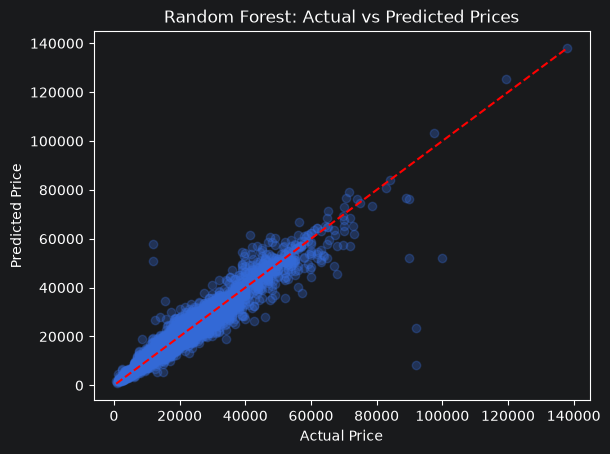

In [89]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

#### TODO: How well it fit the regression line?

##### The model demonstrates a strong fit, as the majority of the predicted points are  tightly around the ideal regression line. There are a few noticeable outliers, which exist because extreme values were not explicitly treated or removed during the data cleaning phase. Despite this, the overall predictive performance remains solid

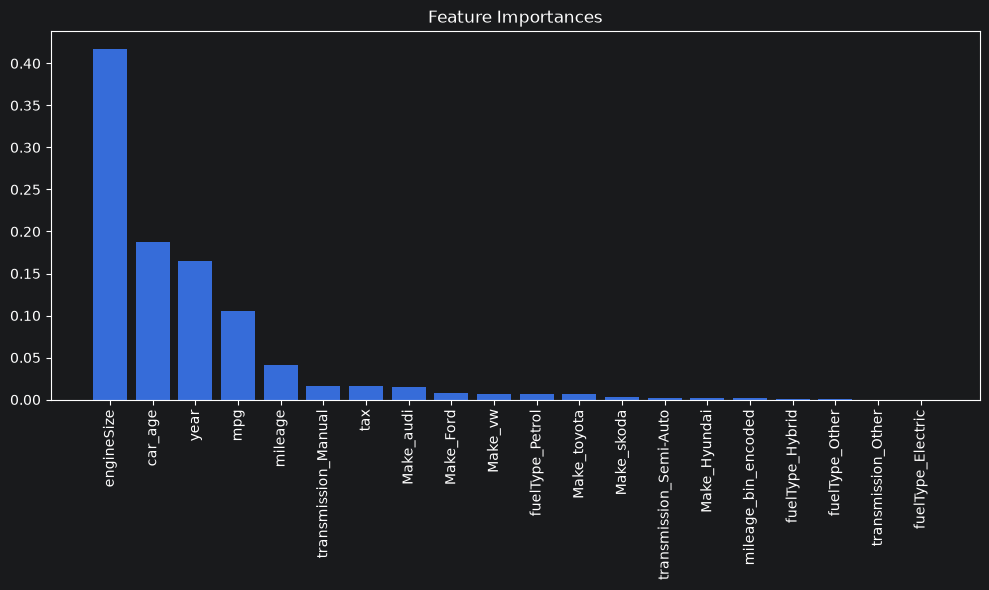

In [90]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()











### 8. Interpret and report
- Summarize model performance.
- Note any limitations or areas for improvement.


### 9. (Optional) Model improvement
- Try more advanced feature engineering.
- Try ensemble methods or stacking.
- Use domain knowledge for custom features.

### 10. Deployment (if needed)
- Prepare pipeline for new data.
- Save model using `joblib` or `pickle`.


### Step 8: Interpret and report
- The developed model performed well, achieving an $R^2$ score of ~94% using the optimal hyperparameters found via Cross-Validation.
- The majority of the prices were well predicted as we can see on the previous diagram.
- Talking about limitations even though the overall performance was high, the model fails to accurately predict the prices for some extreme outliers.
- Although there is a low number of bad predictions compared to the good ones, high-priced cars are significantly undervalued. This suggests that the outliers should be treated separately, or the dataset should be further cleaned so the model can interpret the data more easily.
- After analyzing the good model I played a bit with the hyperparameters , after that I realized how the model predictions and accuracy changes with the hyperparam.
- I understood how the hyper param. works and how the RandomForest works, if we use many trees for our model, the training will be "harder" (longer) but it will give some better results. Talking about the training depth, if the depth is too high there can apper overtraining , the model will fail more often on the test set because the model learn too deeply the train set and fails to predict values for a new set.
- As expected from EDA , the engine size feature is the most important feature in predicting the price

In [ ]:
#Step 10
import joblib

joblib.dump(best_rf, 'car_price_rf_model.pkl')

## TODO: Find the next notebook here in Regression folder, it contains a dataset about house pricings in the USA. Perform Regression and all the learned techniques on it!!! :) Have fun !

## 1. Linear regression model
##### For my personal learning experience at first I will try linear regression as a model, because in the essence is the simplest and maybe the easiest to understand

In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)



##### At first I applied standardization on the tran/test sets because the linear regression is scale sensitive , if we don't apply standardization the weights of the datas will be really hard to interpret after the training.

In [92]:
lin_reg=LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[ 1515.04, -527.31, -174.28,..., -640.53,-1171.16, -304.83]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.656e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(19)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](20,)","[467.54,384.08,332.11,..., 83.5 , 63.28, 0. ]"


In [93]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = lin_reg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 2847.17
RMSE: 4535.54
R²: 0.768


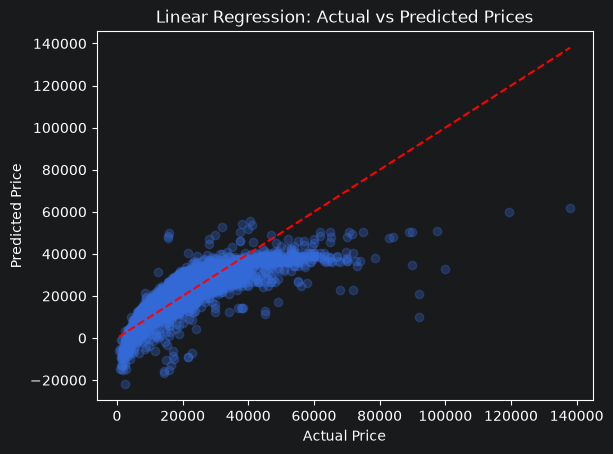

In [94]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

##### As we can see the regression model is not the best , on the basic car the model tends to predict the right price but on the more complex scenarios like old cars or very expensive cars the model fails, why is that? Because the price evolution is hard to predict as a simple line. The biggest problem right now is that the model predict negative prices , wich is impossible when we are talking about price so for an improvement , we have to find how to stop the model from predicting negative prices.

In [95]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)


In [96]:
lin_reg.fit(X_train_scaled, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[ 0.12,-0.1 , 0.02,...,-0.05,-0.09,-0.02]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.583
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(19)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](20,)","[467.54,384.08,332.11,..., 83.5 , 63.28, 0. ]"


In [97]:
y_pred_log = lin_reg.predict(X_test_scaled)
y_pred_real = np.exp(y_pred_log)

mae = mean_absolute_error(y_test, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_real))
r2 = r2_score(y_test, y_pred_real)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 2379.84
RMSE: 3845.75
R²: 0.833


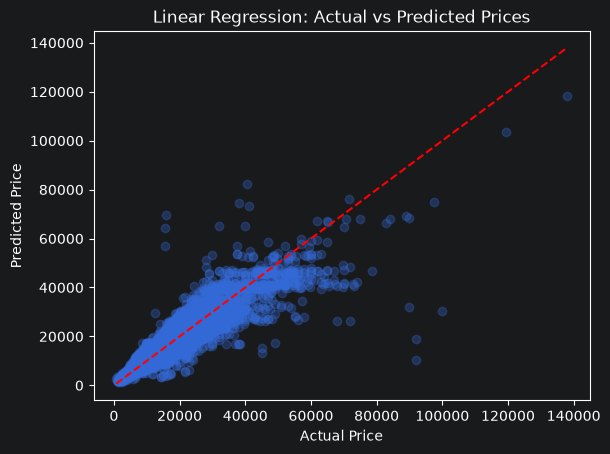

In [98]:
plt.scatter(y_test, y_pred_real, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

##### For the negative prices problem we transformed the price on a ln scale to be easier for the algorithm to work with the price values , because prices can be a very high numbers , transforming them on ln scale all of the numbers will be smaller and easier to work with for the model because the price interval becomes smaller . For the actual negative problem , to have the price in euro as it should be we raise the predicted value at Euler number , and doing that it's impossible to get negative numbers.

In [101]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

log_lin_reg = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log,
    inverse_func=np.exp
)

cv_scores = cross_val_score(
    log_lin_reg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
)

mae_scores = -cv_scores

print(f"MAE Cross-Validation: {mae_scores.mean():.2f}")

MAE Cross-Validation: 2370.25


## Interpret and report
- As expected the Linear Regression Model is not as good as the Random Forest one , because it uses a simpler algorithm behind .
- The metrics were not as bad as I expected after I solved the negative prices problem , having a MAE=~2370 (Using Cross-Validation) RMSE=~3845 and an $R^2$=~83%
- The diagram shows us that the model can predict the normal cars pretty well , but on the outliers fails spectaculary wich is normal for a simple parametric based model.